# Twitter Sentiment Analysis (Multi-Class Emotion Detection)

**Dataset:** 20,000 tweets labeled across 6 emotions : sadness, joy, love, anger, fear, surprise  
**Split:** 16,000 training / 2,000 validation / 2,000 test

### Imports

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

###  Load Data

In [3]:
train_df = pd.read_csv('tweets_training.csv')
val_df   = pd.read_csv('tweets_validation.csv')
test_df  = pd.read_csv('tweets_test.csv')

In [4]:
label_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
train_df['emotion'] = train_df['label'].map(label_map)
val_df['emotion']   = val_df['label'].map(label_map)
test_df['emotion']  = test_df['label'].map(label_map)

### Dataset info

In [5]:
print(f'Training:   {train_df.shape}')
print(f'Validation: {val_df.shape}')
print(f'Test:       {test_df.shape}')

Training:   (16000, 3)
Validation: (2000, 3)
Test:       (2000, 3)


In [6]:
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nNull values:\n{train_df.isnull().sum()}')


Columns: ['text', 'label', 'emotion']

Null values:
text       0
label      0
emotion    0
dtype: int64


In [7]:
train_df.head(10)

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love


## Exploratory Data Analysis (EDA)

### Label Distribution

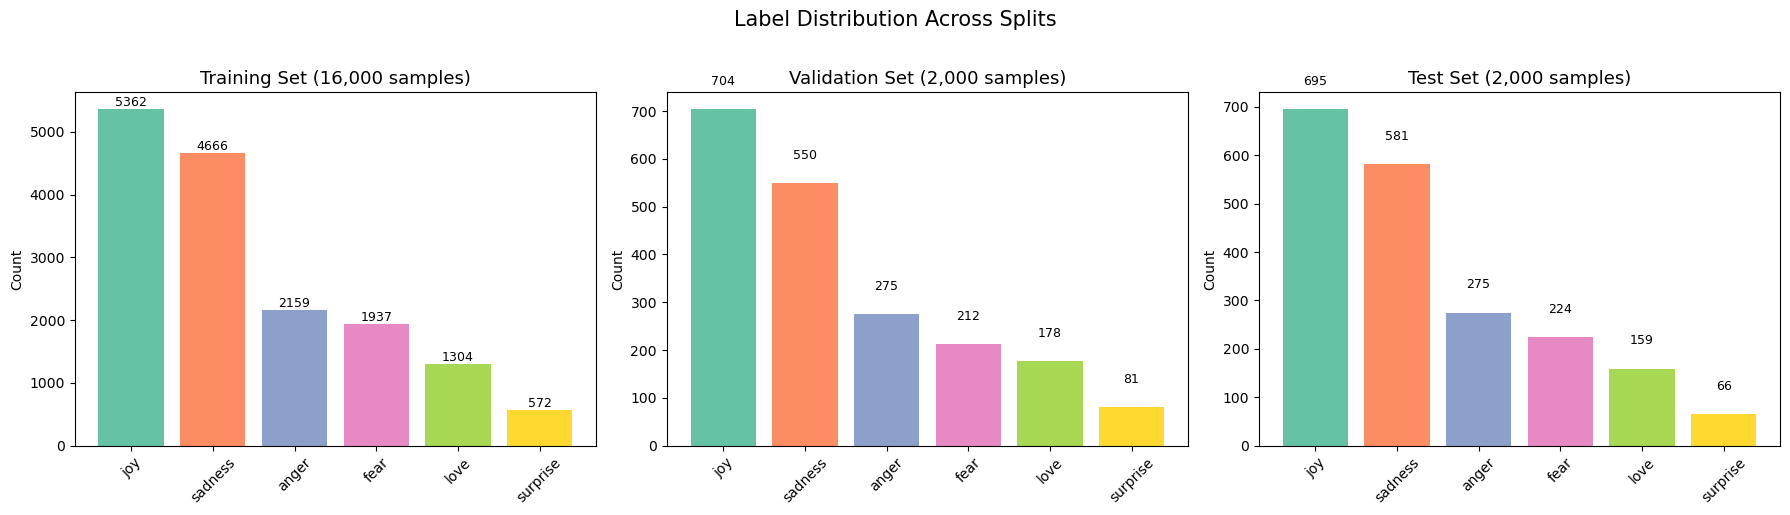

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [('Training', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = df['emotion'].value_counts()
    colors = sns.color_palette('Set2', n_colors=6)
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f'{name} Set ({len(df):,} samples)', fontsize=13)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=9)

plt.suptitle('Label Distribution Across Splits', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print('Training set class percentages:')
print((train_df['emotion'].value_counts(normalize=True) * 100).round(1))

Training set class percentages:
emotion
joy         33.5
sadness     29.2
anger       13.5
fear        12.1
love         8.2
surprise     3.6
Name: proportion, dtype: float64


### Text Length Analysis

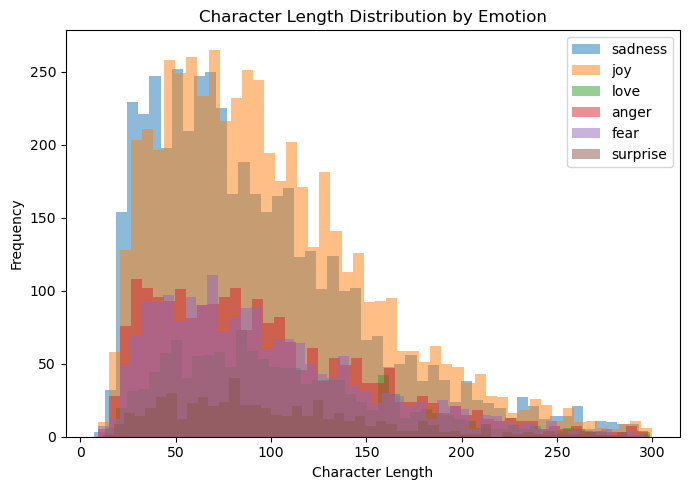

In [10]:
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

plt.figure(figsize=(7, 5))
for emotion in label_map.values():
    subset = train_df[train_df['emotion'] == emotion]
    plt.hist(subset['text_length'], bins=50, alpha=0.5, label=emotion)

plt.title('Character Length Distribution by Emotion')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

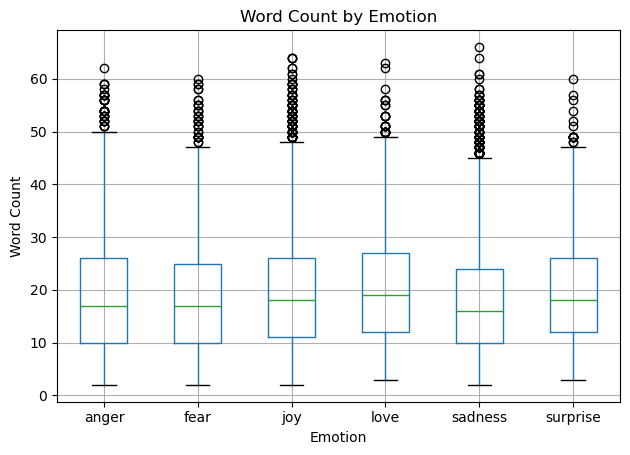

In [11]:
plt.figure(figsize=(7, 5))
train_df.boxplot(column='word_count', by='emotion')
plt.title('Word Count by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()


In [12]:
print('Average word count per emotion:')
print(train_df.groupby('emotion')['word_count'].mean().round(1).sort_values(ascending=False))

Average word count per emotion:
emotion
love        20.7
surprise    20.0
joy         19.5
anger       19.2
fear        18.8
sadness     18.4
Name: word_count, dtype: float64


### Most Common Words per Emotion

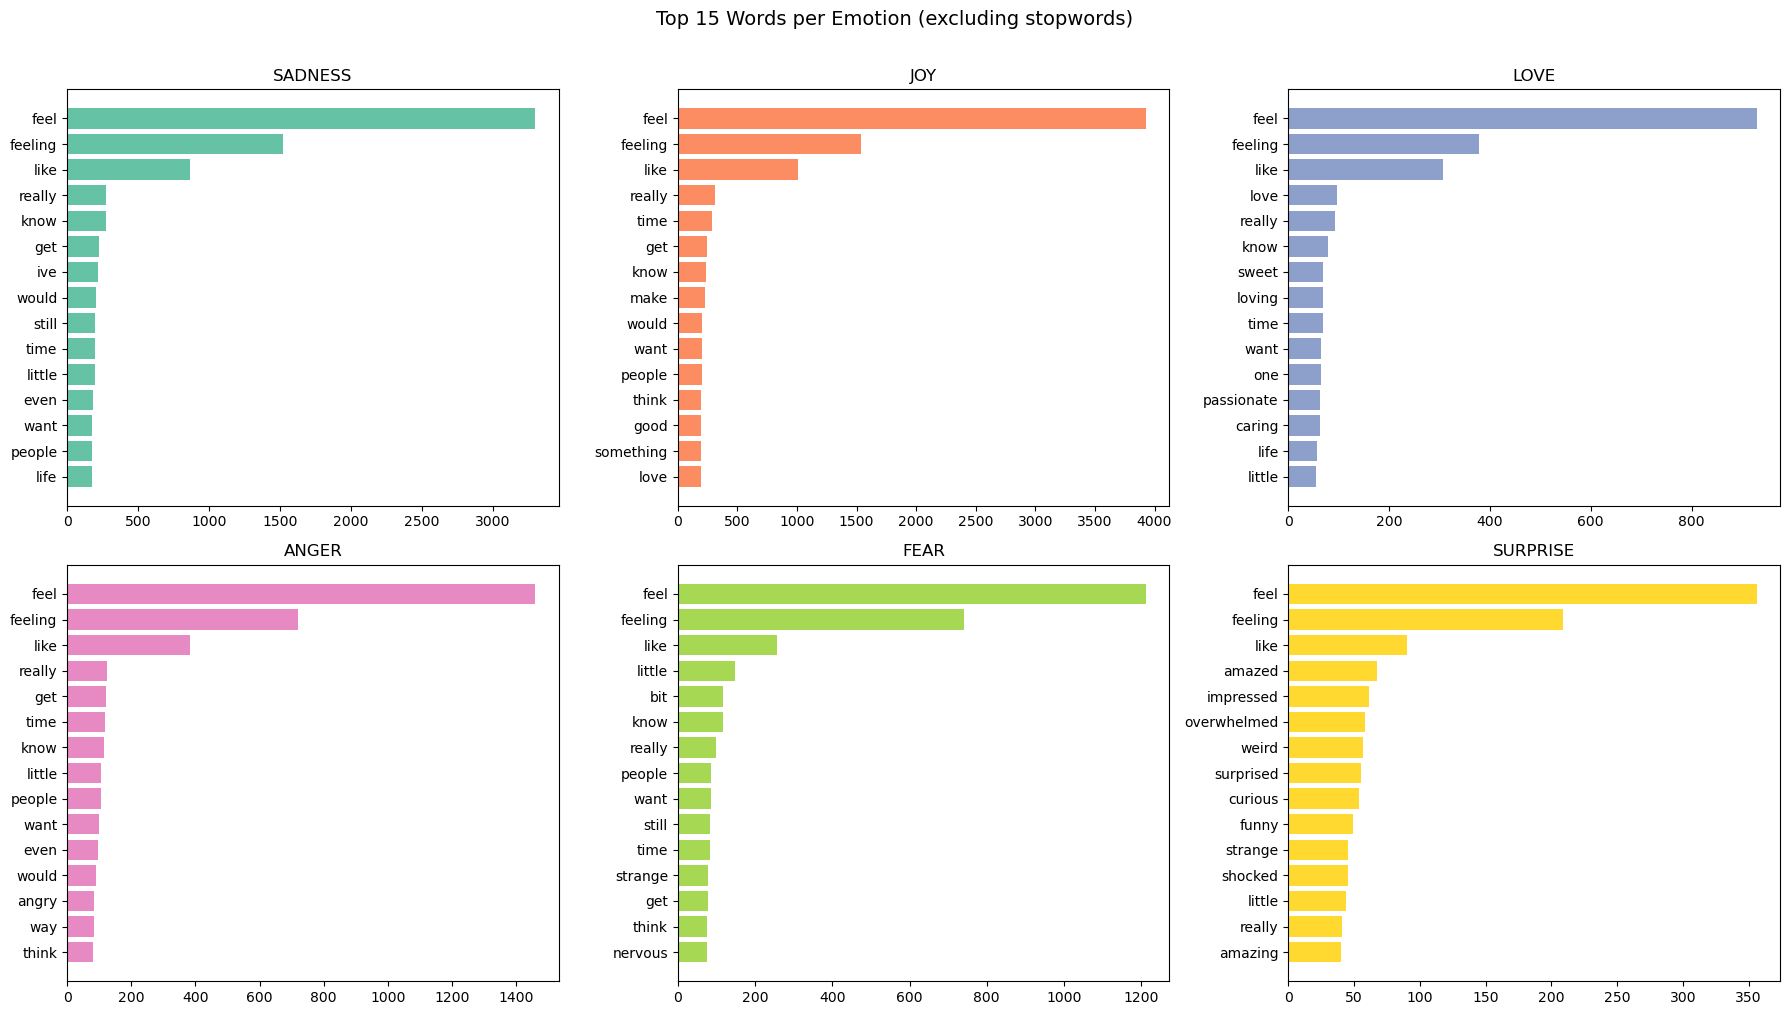

In [13]:
stop_words = set(stopwords.words('english'))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, emotion in zip(axes.flatten(), label_map.values()):
    subset = train_df[train_df['emotion'] == emotion]['text']
    words = ' '.join(subset).split()
    words = [w.lower() for w in words if w.lower() not in stop_words and len(w) > 2]
    common = Counter(words).most_common(15)
    
    ax.barh([w[0] for w in common][::-1], [w[1] for w in common][::-1], color=sns.color_palette('Set2')[list(label_map.values()).index(emotion)])
    ax.set_title(f'{emotion.upper()}', fontsize=12)

plt.suptitle('Top 15 Words per Emotion (excluding stopwords)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Text Preprocessing

In [14]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)      
    text = re.sub(r'@\w+', '', text)                 
    text = re.sub(r'#\w+', '', text)                  
    text = re.sub(r'[^a-zA-Z\s]', '', text)           
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
val_df['clean_text']   = val_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

In [15]:
print('--- Before vs After Preprocessing ---')
for i in range(5):
    print(f'\nOriginal:  {train_df["text"].iloc[i]}')
    print(f'Cleaned:   {train_df["clean_text"].iloc[i]}')

--- Before vs After Preprocessing ---

Original:  i didnt feel humiliated
Cleaned:   didnt feel humiliated

Original:  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned:   feeling hopeless damned hopeful around someone care awake

Original:  im grabbing a minute to post i feel greedy wrong
Cleaned:   grabbing minute post feel greedy wrong

Original:  i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Cleaned:   ever feeling nostalgic fireplace know still property

Original:  i am feeling grouchy
Cleaned:   feeling grouchy


### Impact of Preprocessing on Text Length

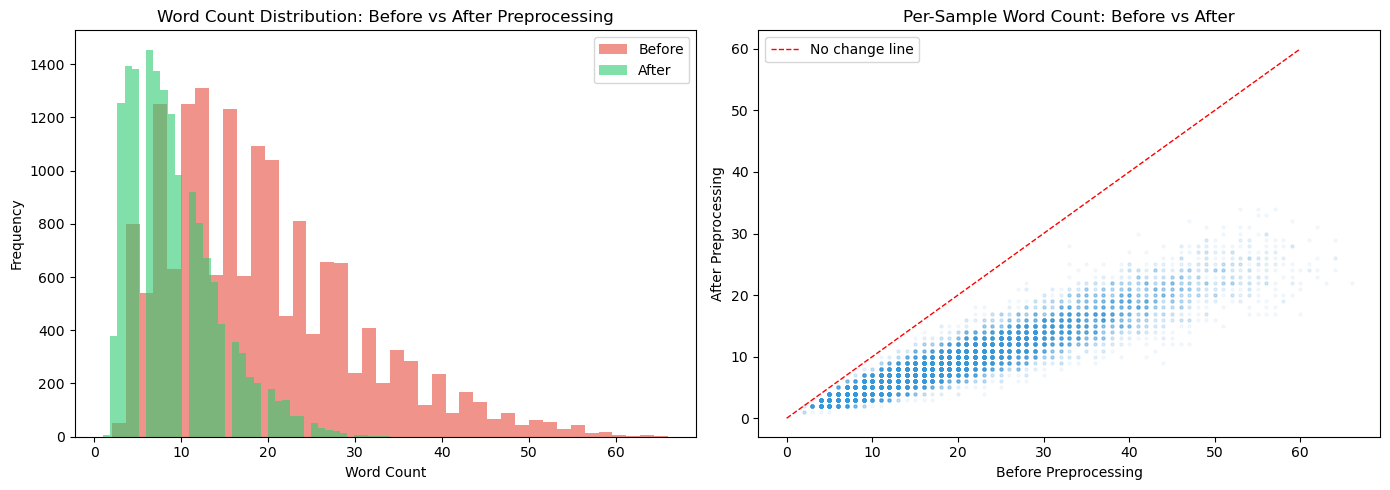

Average word count — Before: 19.2  |  After: 9.1  |  Reduction: 52.5%


In [16]:
train_df['clean_word_count'] = train_df['clean_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['word_count'], bins=40, alpha=0.6, label='Before', color='#e74c3c')
axes[0].hist(train_df['clean_word_count'], bins=40, alpha=0.6, label='After', color='#2ecc71')
axes[0].set_title('Word Count Distribution: Before vs After Preprocessing')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].scatter(train_df['word_count'], train_df['clean_word_count'], alpha=0.05, s=5, color='#3498db')
axes[1].plot([0, 60], [0, 60], 'r--', linewidth=1, label='No change line')
axes[1].set_title('Per-Sample Word Count: Before vs After')
axes[1].set_xlabel('Before Preprocessing')
axes[1].set_ylabel('After Preprocessing')
axes[1].legend()

plt.tight_layout()
plt.show()

avg_before = train_df['word_count'].mean()
avg_after  = train_df['clean_word_count'].mean()
print(f'Average word count — Before: {avg_before:.1f}  |  After: {avg_after:.1f}  |  Reduction: {((avg_before - avg_after)/avg_before)*100:.1f}%')

### Cleaned Text Length by Emotion

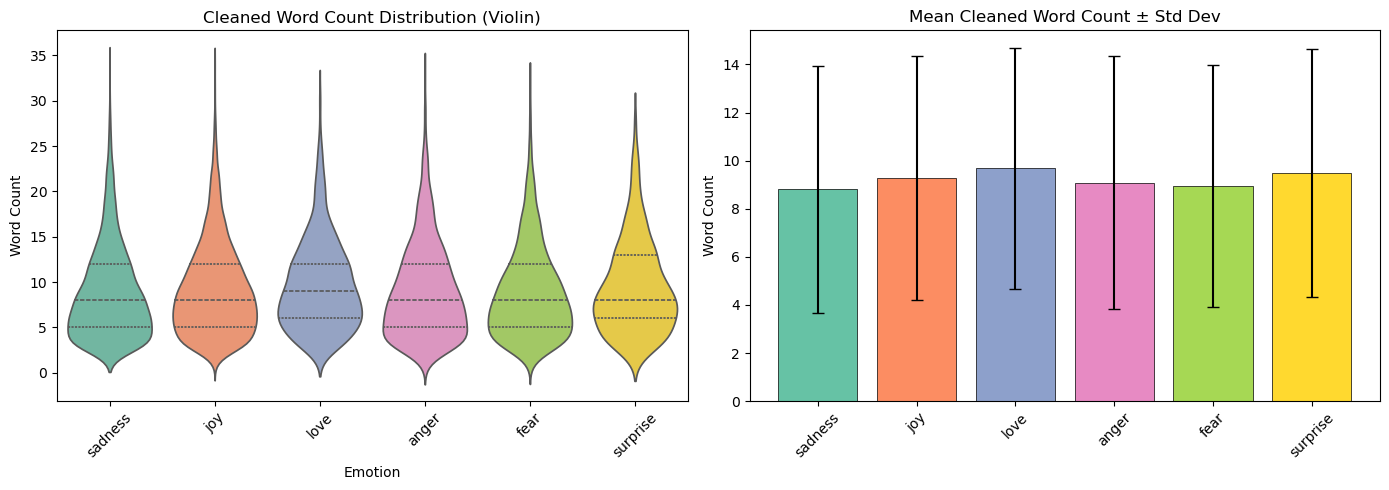

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emotions_order = list(label_map.values())
palette = sns.color_palette('Set2', 6)

sns.violinplot(data=train_df, x='emotion', y='clean_word_count', order=emotions_order,
               palette=palette, inner='quartile', ax=axes[0])
axes[0].set_title('Cleaned Word Count Distribution (Violin)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=45)

stats = train_df.groupby('emotion')['clean_word_count'].agg(['mean', 'std']).loc[emotions_order]
axes[1].bar(stats.index, stats['mean'], yerr=stats['std'], capsize=4,
            color=palette, edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Cleaned Word Count ± Std Dev')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Top Bigrams per Emotion (After Preprocessing)

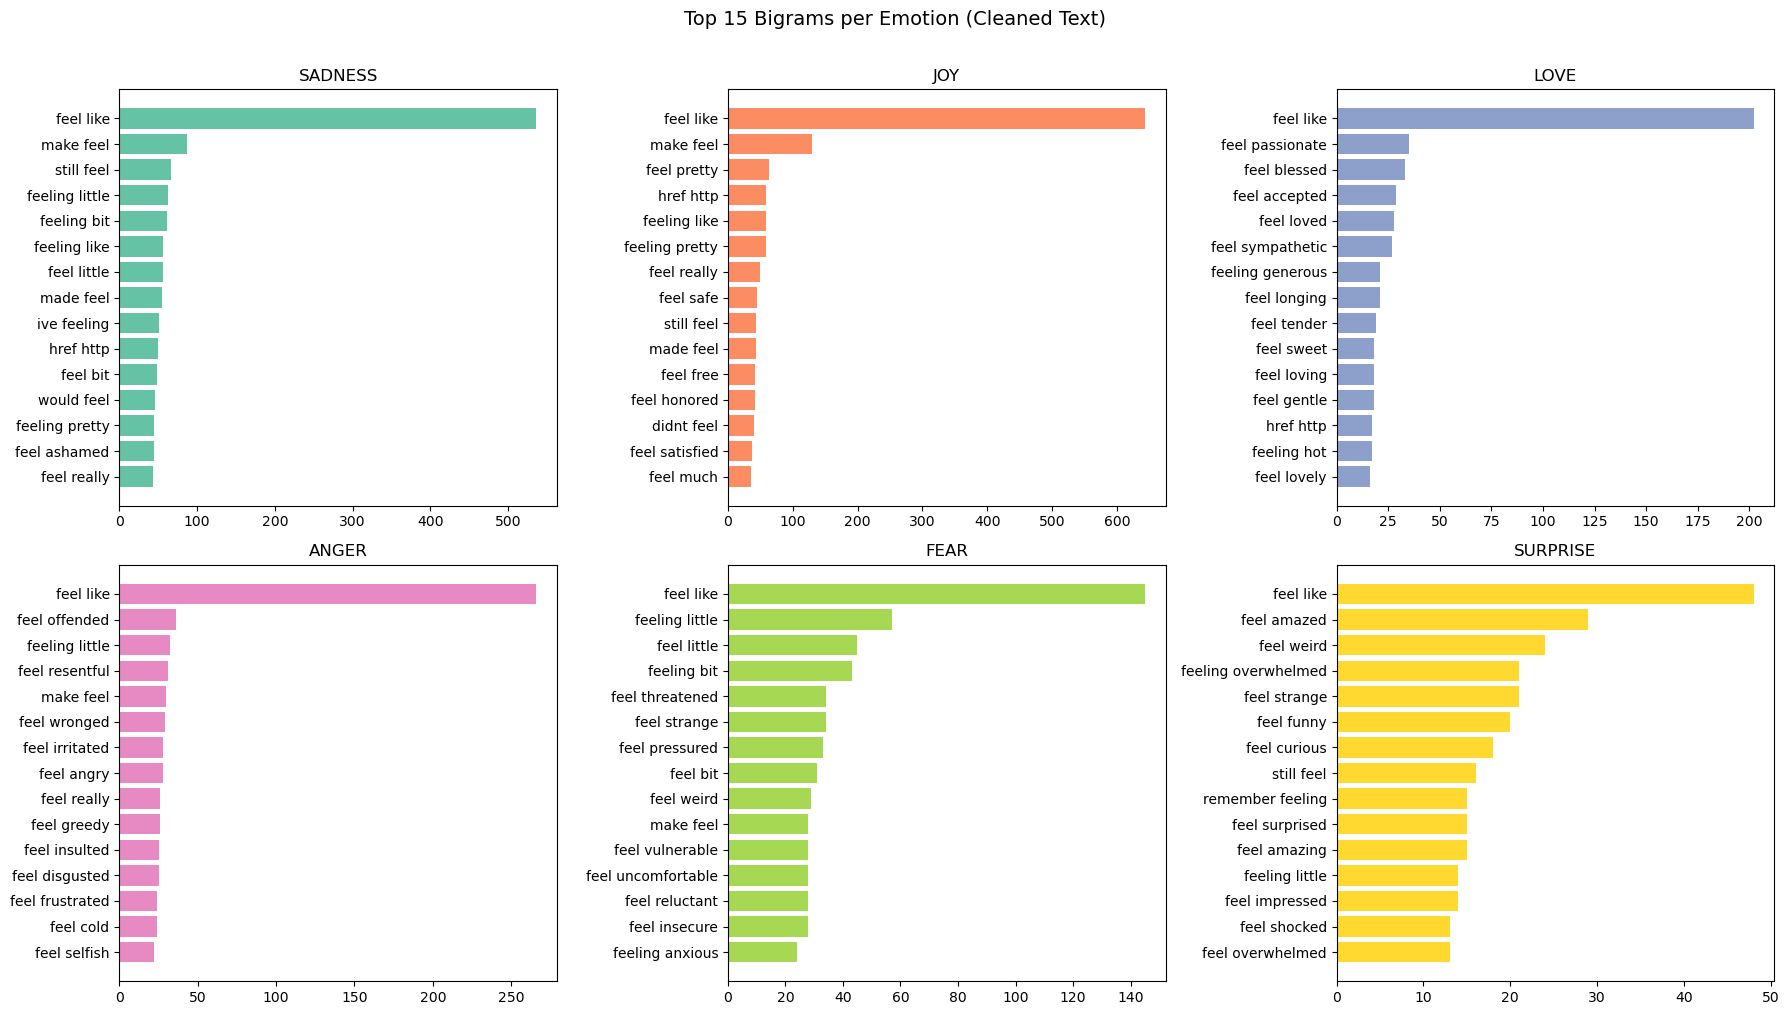

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, emotion in zip(axes.flatten(), label_map.values()):
    subset = train_df[train_df['emotion'] == emotion]['clean_text']
    vec = CountVectorizer(ngram_range=(2, 2), max_features=15)
    X = vec.fit_transform(subset)
    bigram_counts = X.sum(axis=0).A1
    bigrams = vec.get_feature_names_out()
    top_idx = bigram_counts.argsort()[::-1][:15]

    color = palette[list(label_map.values()).index(emotion)]
    ax.barh(bigrams[top_idx][::-1], bigram_counts[top_idx][::-1], color=color)
    ax.set_title(f'{emotion.upper()}')

plt.suptitle('Top 15 Bigrams per Emotion (Cleaned Text)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Word Clouds per Emotion

In [19]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


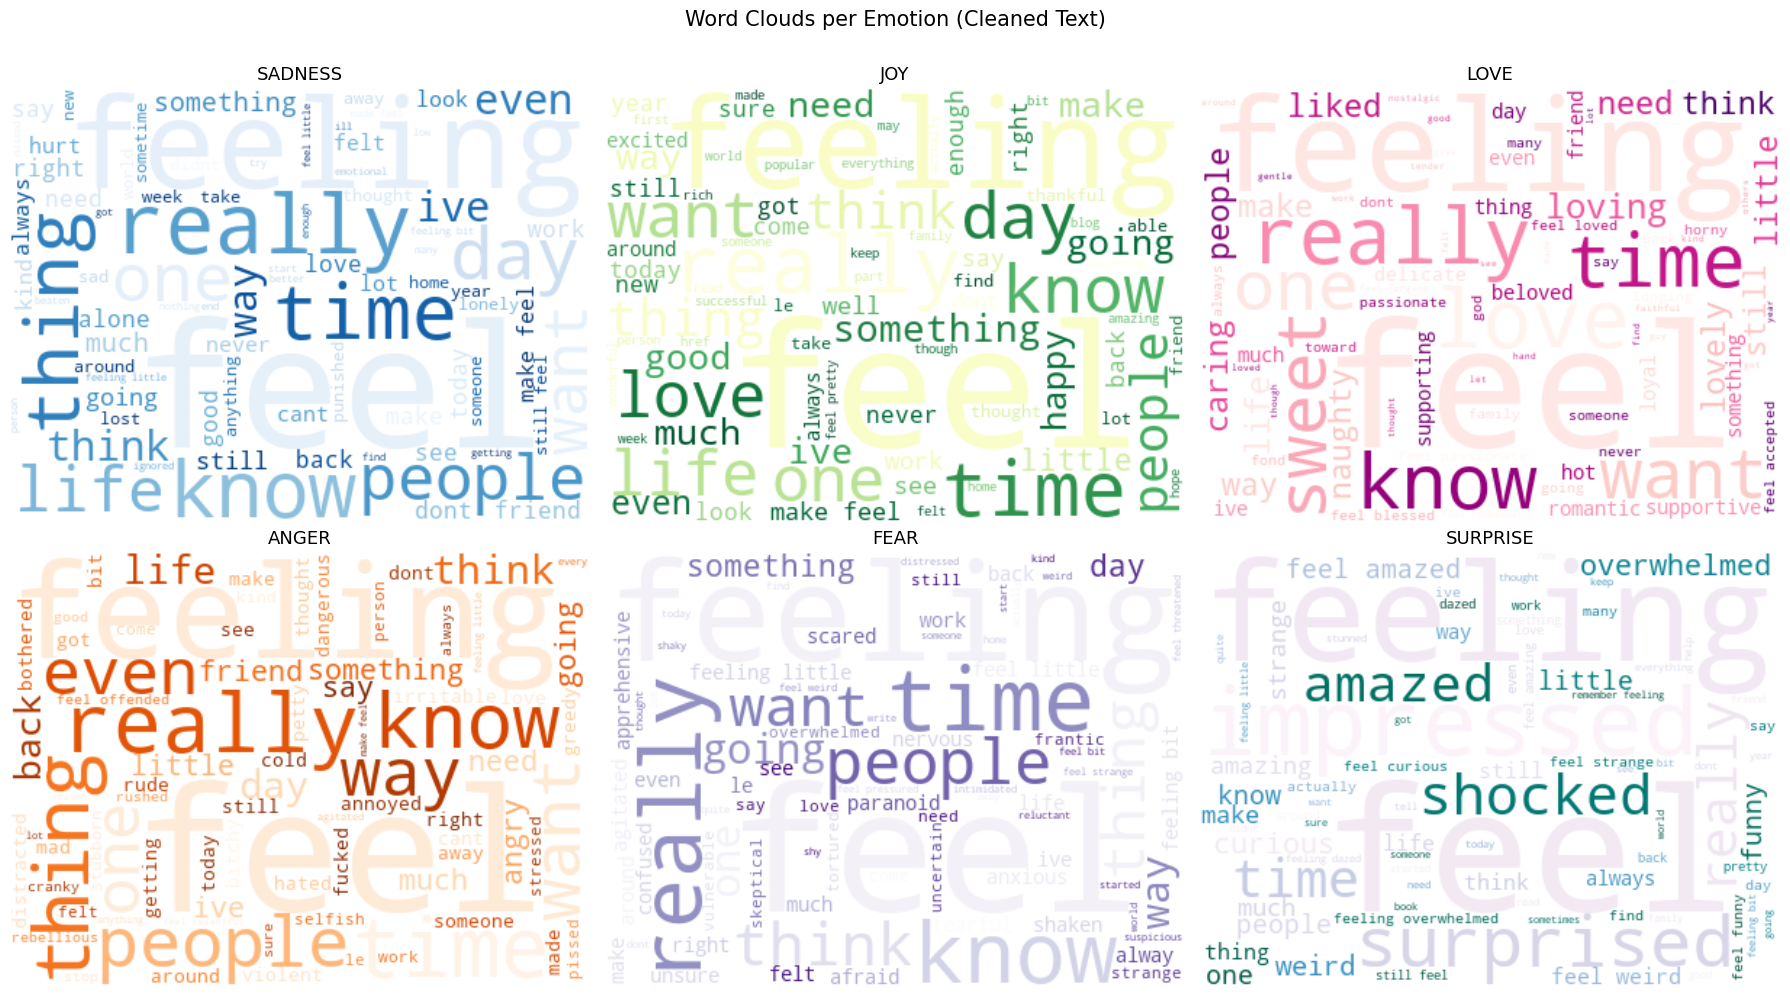

In [20]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_wc = ['Blues', 'YlGn', 'RdPu', 'Oranges', 'Purples', 'PuBuGn']

for ax, emotion, cmap in zip(axes.flatten(), label_map.values(), colors_wc):
    text = ' '.join(train_df[train_df['emotion'] == emotion]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap=cmap, max_words=80, random_state=42)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{emotion.upper()}', fontsize=13)
    ax.axis('off')

plt.suptitle('Word Clouds per Emotion (Cleaned Text)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Text Feature Summary by Emotion

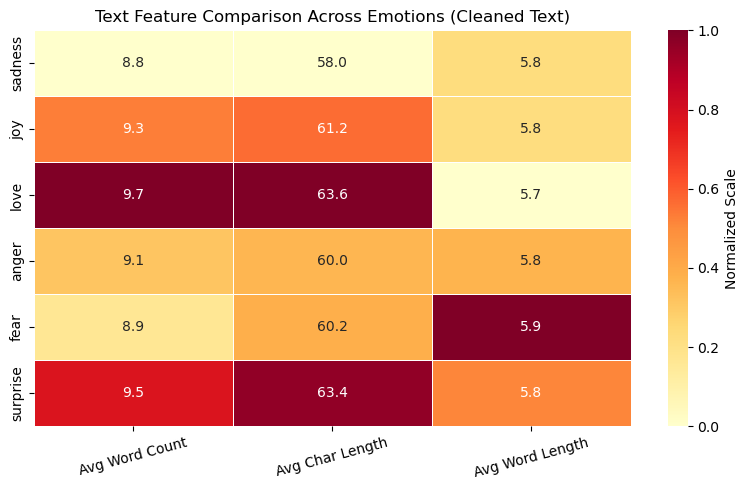

In [21]:
train_df['clean_char_length'] = train_df['clean_text'].str.len()
train_df['avg_word_length']   = train_df['clean_text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x) > 0 else 0)

summary = train_df.groupby('emotion').agg(
    avg_word_count   = ('clean_word_count', 'mean'),
    avg_char_length  = ('clean_char_length', 'mean'),
    avg_word_length  = ('avg_word_length', 'mean'),
    sample_count     = ('emotion', 'count')
).loc[emotions_order]

fig, ax = plt.subplots(figsize=(8, 5))
summary_norm = summary[['avg_word_count', 'avg_char_length', 'avg_word_length']].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()))

sns.heatmap(summary_norm, annot=summary[['avg_word_count', 'avg_char_length', 'avg_word_length']].round(1).values,
            fmt='', cmap='YlOrRd', linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Scale'})
ax.set_title('Text Feature Comparison Across Emotions (Cleaned Text)')
ax.set_ylabel('')
ax.set_xticklabels(['Avg Word Count', 'Avg Char Length', 'Avg Word Length'], rotation=15)

plt.tight_layout()
plt.show()

### Feature Extraction (TF-IDF)

In [22]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)

X_train = tfidf.fit_transform(train_df['clean_text'])
X_val   = tfidf.transform(val_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Training matrix shape:  {X_train.shape}')
print(f'Validation matrix:      {X_val.shape}')
print(f'Test matrix:            {X_test.shape}')

TF-IDF vocabulary size: 10,000
Training matrix shape:  (16000, 10000)
Validation matrix:      (2000, 10000)
Test matrix:            (2000, 10000)


### Model Training & Validation Comparison

Training Logistic Regression...
  Train Accuracy: 0.9551  |  Val Accuracy: 0.8840

Training Linear SVM...
  Train Accuracy: 0.9922  |  Val Accuracy: 0.9045

Training Multinomial NB...
  Train Accuracy: 0.8405  |  Val Accuracy: 0.7620

Training Random Forest...
  Train Accuracy: 0.9976  |  Val Accuracy: 0.8960



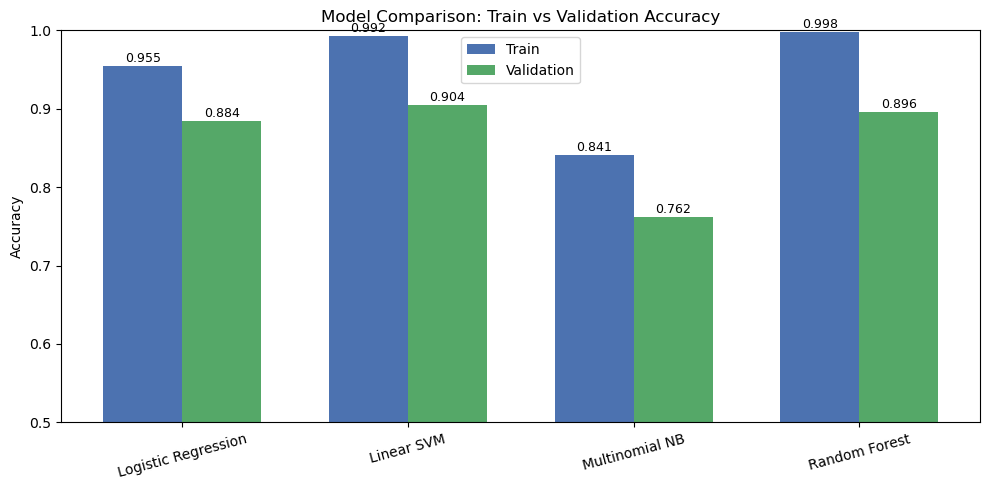

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Multinomial NB':      MultinomialNB(alpha=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc   = accuracy_score(y_val, model.predict(X_val))
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'val_acc': val_acc
    }
    print(f'  Train Accuracy: {train_acc:.4f}  |  Val Accuracy: {val_acc:.4f}')
    print()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.35

train_accs = [r['train_acc'] for r in results.values()]
val_accs   = [r['val_acc'] for r in results.values()]

bars1 = ax.bar(x - width/2, train_accs, width, label='Train', color='#4C72B0')
bars2 = ax.bar(x + width/2, val_accs, width, label='Validation', color='#55A868')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Train vs Validation Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(results.keys(), rotation=15)
ax.legend()
ax.set_ylim(0.5, 1.0)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Final Evaluation on Test Set

In [24]:
best_name = max(results, key=lambda k: results[k]['val_acc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (Val Acc: {results[best_name]["val_acc"]:.4f})')
print('=' * 60)

y_pred = best_model.predict(X_test)

print(f'\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=list(label_map.values())))

Best model: Linear SVM (Val Acc: 0.9045)

Test Accuracy: 0.9000

Classification Report:

              precision    recall  f1-score   support

     sadness       0.92      0.94      0.93       581
         joy       0.91      0.93      0.92       695
        love       0.82      0.80      0.81       159
       anger       0.90      0.89      0.89       275
        fear       0.89      0.85      0.87       224
    surprise       0.73      0.67      0.70        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.90      0.90      0.90      2000



### Confusion Matrix

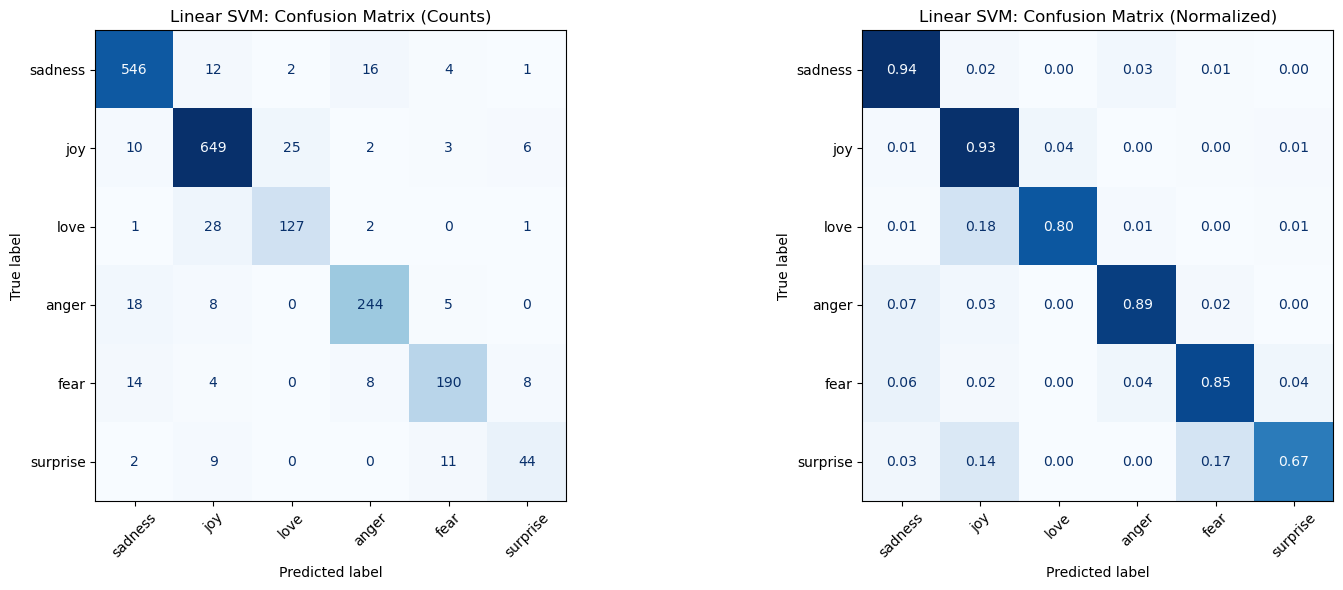

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=list(label_map.values())).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_name}: Confusion Matrix (Counts)')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (percentage)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=list(label_map.values())).plot(ax=axes[1], cmap='Blues', values_format='.2f', colorbar=False)
axes[1].set_title(f'{best_name}: Confusion Matrix (Normalized)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Per-Class Performance

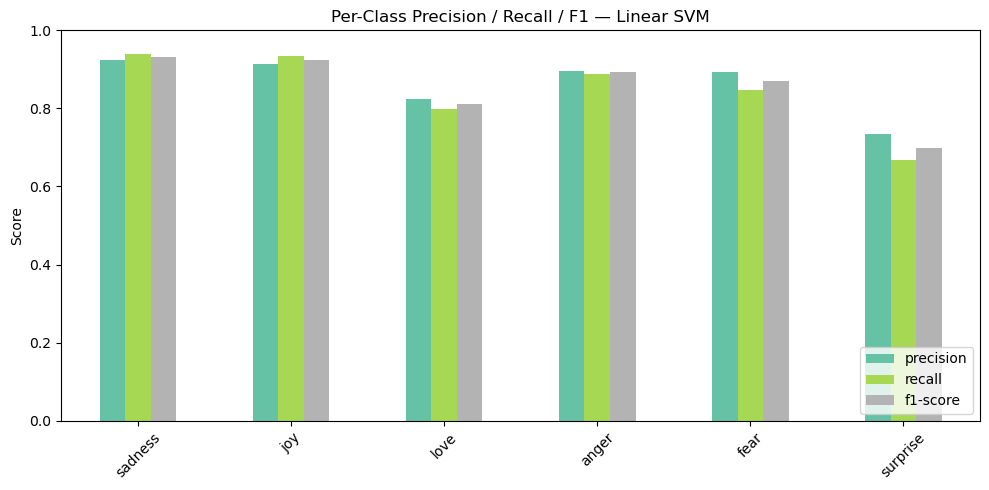

          precision    recall  f1-score  support
sadness    0.923858  0.939759  0.931741      581
joy        0.914085  0.933813  0.923843      695
love       0.824675  0.798742  0.811502      159
anger      0.897059  0.887273  0.892139      275
fear       0.892019  0.848214  0.869565      224
surprise   0.733333  0.666667  0.698413       66


In [26]:
report_dict = classification_report(y_test, y_pred, target_names=list(label_map.values()), output_dict=True)

metrics_df = pd.DataFrame(report_dict).T.iloc[:6]  # only the 6 emotion rows
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df['support'] = metrics_df['support'].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title(f'Per-Class Precision / Recall / F1 — {best_name}')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(metrics_df.to_string())

### Sample Predictions

In [27]:
# Show some correct and misclassified examples
test_df['predicted'] = [label_map[p] for p in y_pred]
test_df['correct']   = test_df['emotion'] == test_df['predicted']

print('--- CORRECT PREDICTIONS ---')
correct = test_df[test_df['correct']].sample(5, random_state=42)
for _, row in correct.iterrows():
    print(f'  Text:      {row["text"][:100]}')
    print(f'  Actual:    {row["emotion"]}  |  Predicted: {row["predicted"]}')
    print()

print('--- MISCLASSIFIED ---')
wrong = test_df[~test_df['correct']].sample(5, random_state=42)
for _, row in wrong.iterrows():
    print(f'  Text:      {row["text"][:100]}')
    print(f'  Actual:    {row["emotion"]}  |  Predicted: {row["predicted"]}')
    print()

--- CORRECT PREDICTIONS ---
  Text:      i know the feel of her losing control against me and trusting me to catch her when she comes apart
  Actual:    joy  |  Predicted: joy

  Text:      i really am not feeling child friendly
  Actual:    joy  |  Predicted: joy

  Text:      i sometimes feel irritated at the thought of spending money on a few annuals to spruce up my doorste
  Actual:    anger  |  Predicted: anger

  Text:      i feel defeated but others i feel refreshed
  Actual:    sadness  |  Predicted: sadness

  Text:      i wasnt very interested in it but it evoked the feeling of an earth grittily doomed by aliens quite 
  Actual:    sadness  |  Predicted: sadness

--- MISCLASSIFIED ---
  Text:      i feel cared for and accepted
  Actual:    love  |  Predicted: joy

  Text:      im feeling generous today heres one more you may have already seen but is good for a chuckle
  Actual:    love  |  Predicted: joy

  Text:      is hand started fondling his aching cock through the fabri

### All Models: Test Set Comparison

In [28]:
print(f'{"Model":<25} {"Train Acc":>10} {"Val Acc":>10} {"Test Acc":>10}')
print('=' * 58)

for name, data in results.items():
    model = data['model']
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{name:<25} {data["train_acc"]:>10.4f} {data["val_acc"]:>10.4f} {test_acc:>10.4f}')

Model                      Train Acc    Val Acc   Test Acc
Logistic Regression           0.9551     0.8840     0.8810
Linear SVM                    0.9922     0.9045     0.9000
Multinomial NB                0.8405     0.7620     0.7690
Random Forest                 0.9976     0.8960     0.8915


### Decision Tree Classifier

Decision Trees are interpretable: every prediction can be traced through a sequence of word-presence rules. They tend to overfit on high-dimensional sparse text features, so we use `max_depth` and `min_samples_split` to control complexity.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_val_acc   = accuracy_score(y_val,   dt.predict(X_val))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f'Decision Tree Results:')
print(f'  Train Accuracy:    {dt_train_acc:.4f}')
print(f'  Val Accuracy:      {dt_val_acc:.4f}')
print(f'  Test Accuracy:     {dt_test_acc:.4f}')
print(f'  Tree depth:        {dt.get_depth()}')
print(f'  Number of leaves:  {dt.get_n_leaves()}')

Decision Tree Results:
  Train Accuracy:    0.4161
  Val Accuracy:      0.4150
  Test Accuracy:     0.4030
  Tree depth:        20
  Number of leaves:  97


#### Visualize the Tree (depth-limited for readability)

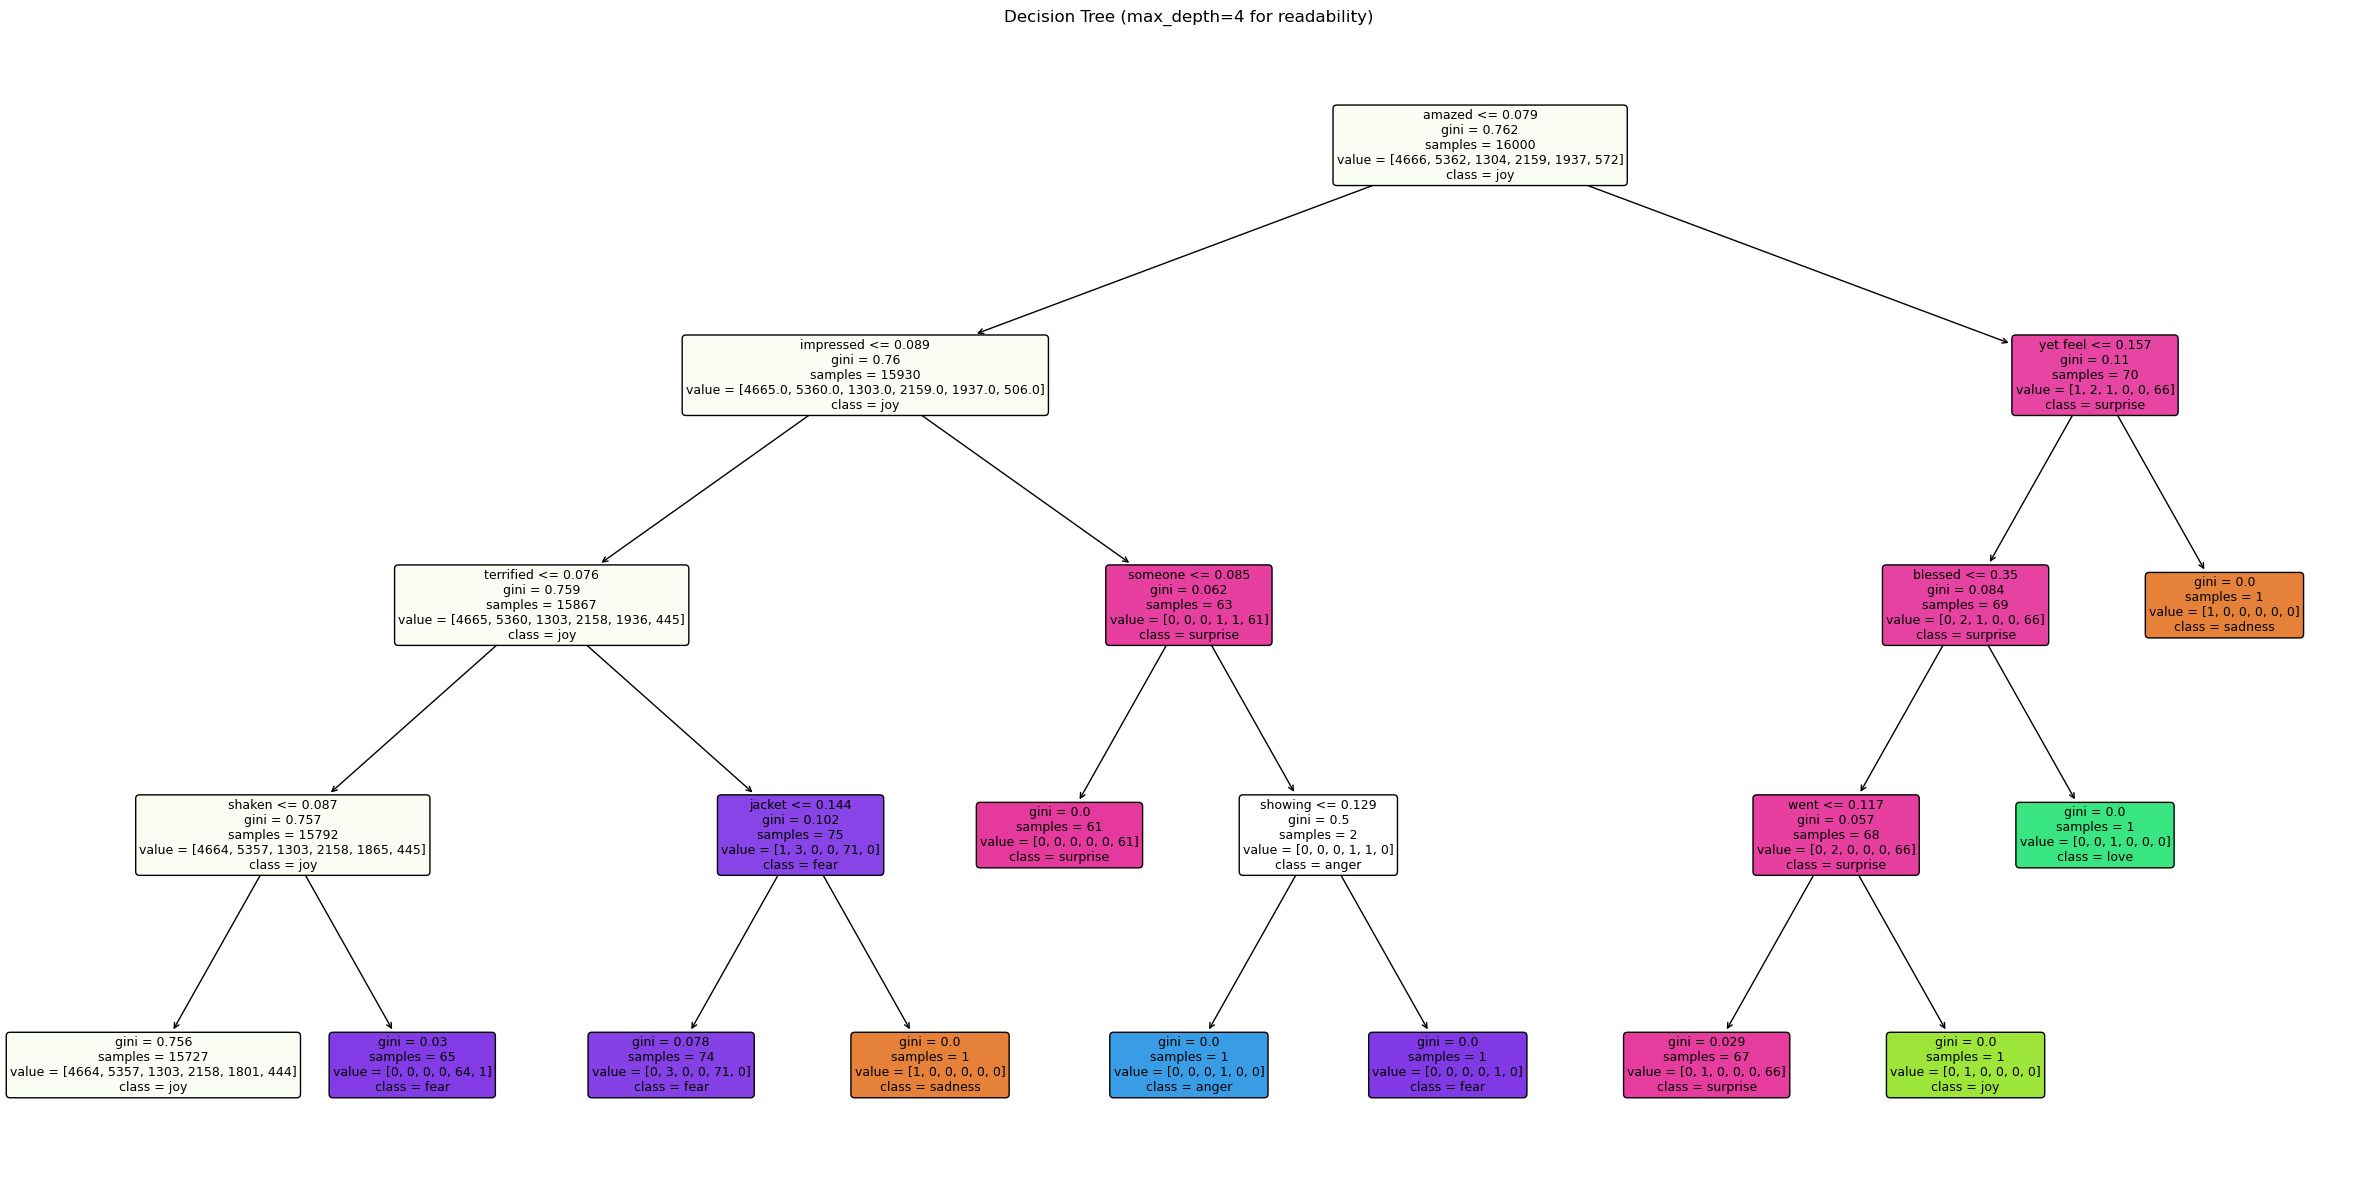

Shallow tree val accuracy: 0.3670
(shallow tree is for interpretation only; the deeper tree above is used in the final comparison)


In [ ]:
dt_shallow = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_shallow.fit(X_train, y_train)

feature_names = tfidf.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    dt_shallow,
    feature_names=feature_names,
    class_names=list(label_map.values()),
    filled=True, rounded=True, fontsize=9, max_depth=4
)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

print(f'Shallow tree val accuracy: {accuracy_score(y_val, dt_shallow.predict(X_val)):.4f}')

#### Top Features by Gini Importance

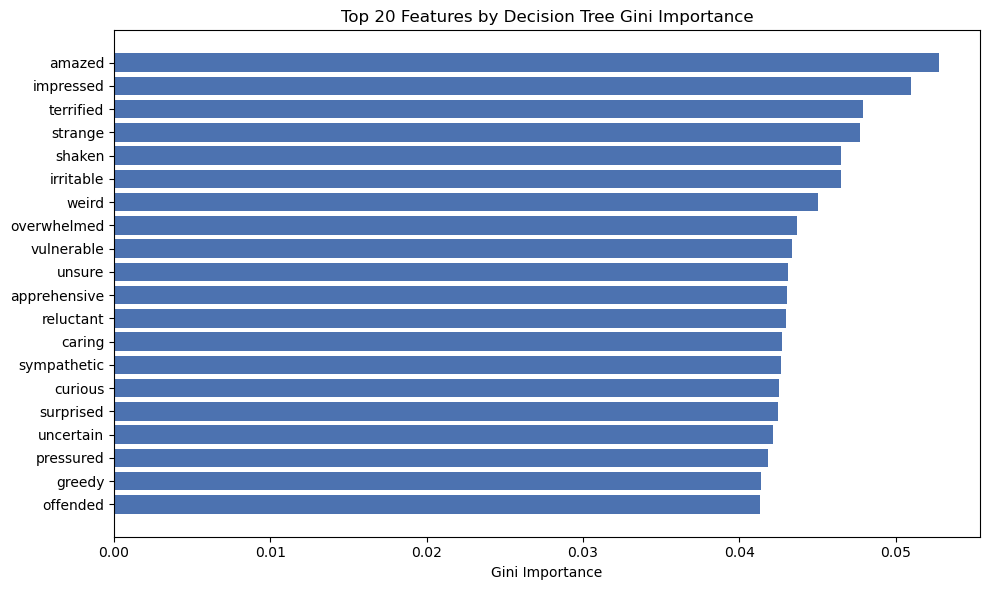

In [84]:
# Top features ranked by Gini reduction across the deep tree
importances = dt.feature_importances_
top_n = 20
top_indices = importances.argsort()[-top_n:][::-1]
top_features = [(feature_names[i], importances[i]) for i in top_indices]

plt.figure(figsize=(10, 6))
features, scores = zip(*top_features)
plt.barh(range(top_n), scores[::-1], color='#4C72B0')
plt.yticks(range(top_n), features[::-1])
plt.xlabel('Gini Importance')
plt.title(f'Top {top_n} Features by Decision Tree Gini Importance')
plt.tight_layout()
plt.show()

### KNN Classifier

**Critical**: using **cosine similarity** , not Euclidean. Euclidean distance is poor for sparse high-dimensional text features because most distances become similar. Cosine measures angular similarity and works well on TF-IDF.


In [85]:
from sklearn.neighbors import KNeighborsClassifier
import time

# Sweep k values to find the best
k_values = [3, 5, 7, 11, 15]
knn_results = {}

for k_val in k_values:
    print(f'Training KNN (k={k_val})...')
    start = time.time()

    knn = KNeighborsClassifier(n_neighbors=k_val, metric='cosine', algorithm='brute', n_jobs=-1)
    knn.fit(X_train, y_train)

    val_acc = accuracy_score(y_val, knn.predict(X_val))
    elapsed = time.time() - start

    knn_results[k_val] = {'val_acc': val_acc, 'time': elapsed}
    print(f'  Val Accuracy: {val_acc:.4f}  |  Time: {elapsed:.1f}s')

print('\nKNN Sweep Results:')
for k_val, res in knn_results.items():
    print(f'  k={k_val:2d}: val_acc={res["val_acc"]:.4f}, time={res["time"]:.1f}s')

Training KNN (k=3)...
  Val Accuracy: 0.6945  |  Time: 0.8s
Training KNN (k=5)...
  Val Accuracy: 0.7270  |  Time: 0.9s
Training KNN (k=7)...
  Val Accuracy: 0.7440  |  Time: 0.8s
Training KNN (k=11)...
  Val Accuracy: 0.7540  |  Time: 0.9s
Training KNN (k=15)...
  Val Accuracy: 0.7730  |  Time: 0.8s

KNN Sweep Results:
  k= 3: val_acc=0.6945, time=0.8s
  k= 5: val_acc=0.7270, time=0.9s
  k= 7: val_acc=0.7440, time=0.8s
  k=11: val_acc=0.7540, time=0.9s
  k=15: val_acc=0.7730, time=0.8s


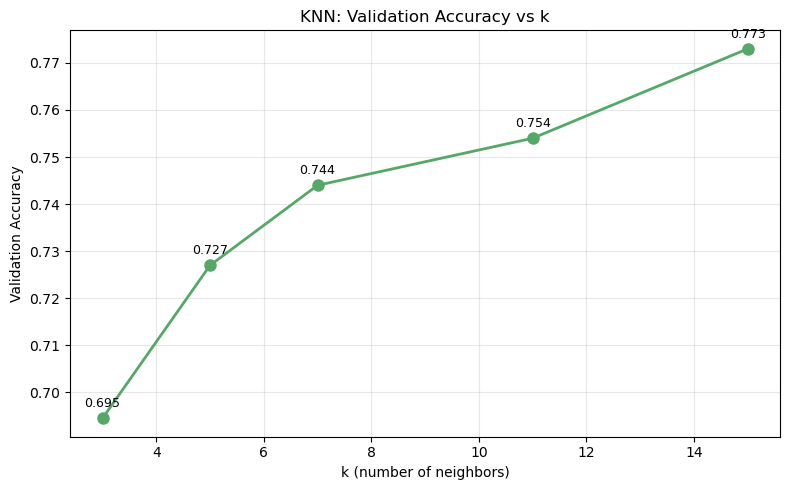

In [ ]:
plt.figure(figsize=(8, 5))
ks = list(knn_results.keys())
vals = [knn_results[k]['val_acc'] for k in ks]

plt.plot(ks, vals, 'o-', color='#55A868', linewidth=2, markersize=8)
plt.xlabel('k (number of neighbors)')
plt.ylabel('Validation Accuracy')
plt.title('KNN: Validation Accuracy vs k')
plt.grid(alpha=0.3)
for k_val, v in zip(ks, vals):
    plt.annotate(f'{v:.3f}', (k_val, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
best_k = max(knn_results, key=lambda k: knn_results[k]['val_acc'])
print(f'Best k: {best_k} (val_acc: {knn_results[best_k]["val_acc"]:.4f})')

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute', n_jobs=-1)
knn_best.fit(X_train, y_train)
knn_test_acc = accuracy_score(y_test, knn_best.predict(X_test))
print(f'KNN Test Accuracy: {knn_test_acc:.4f}')

Best k: 15 (val_acc: 0.7730)
KNN Test Accuracy: 0.7775


### Final Model Comparison

In [ ]:
all_models = {}

for name, data in results.items():
    model = data['model']
    all_models[name] = {
        'train_acc': data['train_acc'],
        'val_acc':   data['val_acc'],
        'test_acc':  accuracy_score(y_test, model.predict(X_test))
    }

all_models['Decision Tree'] = {
    'train_acc': dt_train_acc,
    'val_acc':   dt_val_acc,
    'test_acc':  dt_test_acc
}

all_models[f'KNN (k={best_k})'] = {
    'train_acc': np.nan,  # skipped for speed
    'val_acc':   knn_results[best_k]['val_acc'],
    'test_acc':  knn_test_acc
}

comp_df = pd.DataFrame(all_models).T[['train_acc', 'val_acc', 'test_acc']]
comp_df.columns = ['Train', 'Validation', 'Test']
comp_df = comp_df.sort_values('Test', ascending=False)

print('Final Model Comparison (sorted by Test Accuracy):\n')
print(comp_df.round(4).to_string())

Final Model Comparison (sorted by Test Accuracy):

                      Train  Validation    Test
Linear SVM           0.9922      0.9045  0.9000
Random Forest        0.9976      0.8960  0.8915
Logistic Regression  0.9551      0.8840  0.8810
KNN (k=15)              NaN      0.7730  0.7775
Multinomial NB       0.8405      0.7620  0.7690
Decision Tree        0.4161      0.4150  0.4030


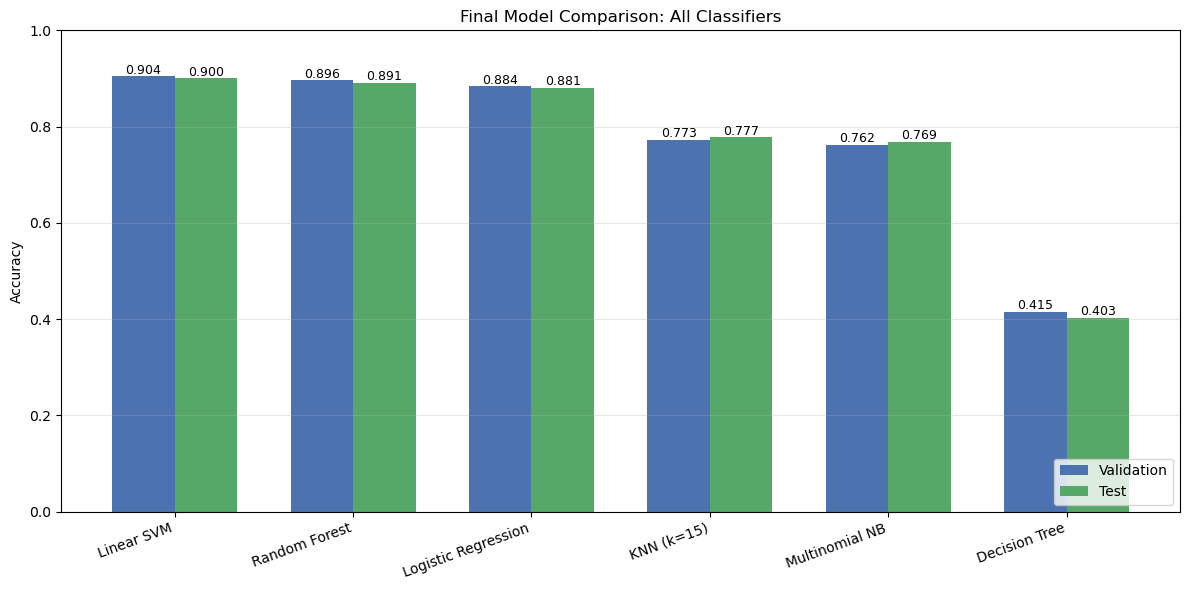

In [91]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp_df))
width = 0.35

bars1 = ax.bar(x - width/2, comp_df['Validation'], width, label='Validation', color='#4C72B0')
bars2 = ax.bar(x + width/2, comp_df['Test'],       width, label='Test',       color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Final Model Comparison: All Classifiers')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()